# **1. 서울 자전거 공유 수요 데이터셋**
서울시의 공공자전거 대여 서비스인 ‘따릉이’의 대여 수요를 예측하는 문제에 사용되는 데이터셋이다. 특정 시간대와 날씨, 요일, 공휴일 여부, 기온, 습도 등 다양한 데이터를 활용하여 자전거 대여 수요를 예측한다.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### ※ CP949

- Microsoft Windows의 한국어 문자 인코딩입니다.
- EUC-KR을 확장한 형태로, 더 많은 한국어 문자(한자, 확장 문자 등)를 지원합니다.
- 주로 Windows 환경에서 저장된 한글 파일에서 사용됩니다.

In [30]:
data_path = Path('./source/SeoulBikeData.csv')
bike_raw = pd.read_csv(data_path, encoding='CP949')
bike_raw

,Date,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


# 2. 데이터셋 컬럼
```
Date: 연월일
Rented Bike count - 매 시간마다 대여한 자전거 수
Hour - 하루 중 시간
Temperature - 온도
Humidity - 습도 %
Windspeed - 풍속 m/s
Visibility - 가시거리 m
Dew point temperature - 이슬점 온도
Solar radiation - 태양 복사 MJ/m2
Rainfall - 강우량 mm
Snowfall - 적설량 cm
Seasons - 겨울, 봄, 여름, 가을
Holiday - 휴일/휴일 없음
Functional Day - 운영되지 않았던 날, 정상적으로 운영된 날
```

# **3. 데이터 전처리 및 탐색적 데이터 분석 (EDA)**

In [31]:
bike_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   str    
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(캜)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(캜)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   str    
 12  Holiday                   8760 non-null   str    
 13  Functioning Day           8760 non-null   str    
dtypes: float64(6), int6

In [32]:
bike_raw.describe()

,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [33]:
bike_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8760,365,01/12/2017,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
Hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
Temperature(캜),8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
Humidity(%),8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
Wind speed (m/s),8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
Visibility (10m),8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
Dew point temperature(캜),8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
Solar Radiation (MJ/m2),8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
Rainfall(mm),8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0


In [34]:
bike_df = bike_raw.copy()
bike_df.columns = [
    'Date', 'Rented Bike Count', 'Hour', 'Temperature', 'Humidity',
    'Wind speed', 'Visibility', 'Dew point temperature',
    'Solar Radiation', 'Rainfall', 'Snowfall', 'Seasons',
    'Holiday', 'Functioning Day'
]
bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [35]:
# 이후 project에서 DataFrame title만 바꿔서 결측치를 확인하면 됨
quality_report = pd.DataFrame({
    'missing_count': bike_df.isna().sum(),
    'missing_ratio': bike_df.isna().mean(),
    'nunique': bike_df.nunique()
})
print('중복 행 개수:', bike_df.duplicated().sum())
print(quality_report)

중복 행 개수: 0
                       missing_count  missing_ratio  nunique
Date                               0            0.0      365
Rented Bike Count                  0            0.0     2166
Hour                               0            0.0       24
Temperature                        0            0.0      546
Humidity                           0            0.0       90
Wind speed                         0            0.0       65
Visibility                         0            0.0     1789
Dew point temperature              0            0.0      556
Solar Radiation                    0            0.0      345
Rainfall                           0            0.0       61
Snowfall                           0            0.0       51
Seasons                            0            0.0        4
Holiday                            0            0.0        2
Functioning Day                    0            0.0        2


# **4. EDA**
Exploratory Data analysis(탐색적 데이터 분석)의 약자로, 데이터를 본격적으로 모델링하거나 가설을 검증하기 전에 **데이터의 구조, 특성, 패턴, 이상치, 변수 간의 관계를 이해하는 과정**이다.

### 1. EDA의 목적
- 데이터의 전체적인 구조 파악
- 결측치 확인
- 이상치 탐색
- 변수의 분포 확인
- 변수 간 관계 분석
- 데이터 품질 문제 발견
- 모델링 전에 전처리 방향 결정
- 새로운 가설 생성

### 2. 전체 과정

1. 데이터 불러오기
2. 데이터 구조 확인
3. 기초 통계 확인
4. 결측치 확인
5. 이상치 확인
6. 단변량 분석 - 한 칼럼의 특징만 집중적으로 분석
7. 다변량 분석 - 두 개 이상의 칼럼 사이에 어떠한 관계가 있는 지 분석 
8. 시각화
9. 인사이트 도출
10. 전처리 방향 결정

# **5. 날짜 처리와 피처 엔지니어링**
Date는 문자열 그대로 모델에 넣을 수 없다. 그래서 날짜를 여러 의미있는 변수로 나눈다.
- year, month, day
- dayofweek: 월요일 0, 일요일 6
- is_weekend: 주말 여부
- hour_sin, hour_cos: 23시와 0시가 가깝다는 것을 모델에 알려주는 주기형 인코딩
- month_sin, month_cos: 12월과 1월이 가깝다는 것을 모델에 알려주는 주기형 인코딩

In [36]:
bike_df['Date'] = pd.to_datetime(bike_df['Date'], format='%d/%m/%Y')
bike_df['year'] = bike_df['Date'].dt.year
bike_df['month'] = bike_df['Date'].dt.month
bike_df['day'] = bike_df['Date'].dt.day
bike_df['dayofweek'] = bike_df['Date'].dt.dayofweek
bike_df['is_weekend'] = bike_df['dayofweek'].isin([5, 6]).astype(int)
bike_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,year,month,day,dayofweek,is_weekend
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017,12,1,4,0


In [38]:
# 시간과 월은 반복되는 순환구조
# 머신러닝: 0 < 1 < 2 < ... < 23으로 인식, 실제: 23 > 0 -> 주기성 문제
# 2 * np.pi * bike_df['Hour'] / 24 -> 각도로 변환
# sin() 적용 -> 0, 1, 0, -1, 0 -> 주기적이지만 12시와 0시가 구분이 안됨
# cos() 적용 -> 1, 0, -1, 0, 1 -> sin()과 cos()을 쌍으로 학습하면 다른 시간임을 알 수 있음
bike_df['hour_sin'] = np.sin(2 * np.pi * bike_df['Hour'] / 24)
bike_df['hour_cos'] = np.cos(2 * np.pi * bike_df['Hour'] / 24)
bike_df['month_sin'] = np.sin(2 * np.pi * bike_df['month'] / 12)
bike_df['month_sin'] = np.cos(2 * np.pi * bike_df['month'] / 12)
bike_df.head()
# 날짜도 순환구조로 표현할 수 있지만 월로 구별되기 때문에 따로 하지 않았음, 그러나 중요하다면 하는 것도 좋음

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,...,Holiday,Functioning Day,year,month,day,dayofweek,is_weekend,hour_sin,hour_cos,month_sin
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,No Holiday,Yes,2017,12,1,4,0,0.000000,1.000000,1.0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,No Holiday,Yes,2017,12,1,4,0,0.258819,0.965926,1.0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,No Holiday,Yes,2017,12,1,4,0,0.500000,0.866025,1.0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,No Holiday,Yes,2017,12,1,4,0,0.707107,0.707107,1.0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,No Holiday,Yes,2017,12,1,4,0,0.866025,0.500000,1.0


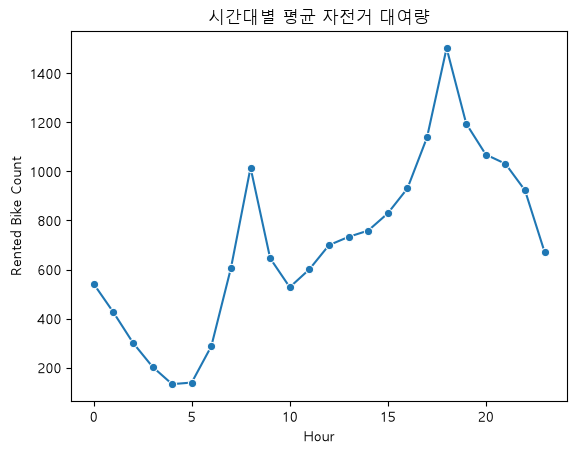

In [44]:
hourly_demand = bike_df.groupby('Hour')['Rented Bike Count'].mean().reset_index()

# 시간대별 평균 자전거 대여량 시각화
sns.lineplot(data=hourly_demand, x='Hour', y='Rented Bike Count', marker='o')
plt.title('시간대별 평균 자전거 대여량')
plt.show()

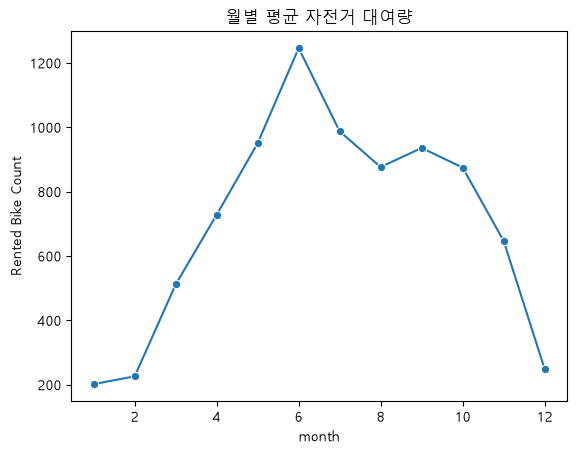

In [47]:
monthly_demand = bike_df.groupby('month')['Rented Bike Count'].mean().reset_index()

# 월별 평균 자전거 대여량 시각화
sns.lineplot(data=monthly_demand, x='month', y='Rented Bike Count', marker='o')
plt.title('월별 평균 자전거 대여량')
plt.show()

> Seaborn의 barplot은 범주형 데이터(x)에 대해 수치형 데이터(y)의 통계 요약값을 계산하여 막대로 시각화하는 그래프로, 기본적으로 각 범주별 평균(mean)을 사용하며 평균의 불확실성을 나타내는 신뢰구간(error bar)을 함께 표시한다. 내부적으로는 groupby와 집계 과정을 자동으로 수행하여 원본 데이터의 개수와 상관없이 범주 수만큼의 막대가 생성되며, estimator 옵션을 통해 평균 대신 합계·중앙값·개수 등으로 변경할 수 있고, hue를 사용하면 추가 범주에 따른 비교도 가능하다. 즉, seaborn barplot은 값 자체가 아니라 집단 간 통계적 대표값을 비교하기 위한 시각화 도구이다.

### ※ Seaborn의 barplot 을 읽는 법

1) 먼저 “막대가 뭘 뜻하는지”부터 확인한다. Seaborn barplot의 막대 높이는 기본적으로 평균(mean)이다.
    -  x축(또는 y축)에 있는 각 범주(category) 별로 y값(수치형)의 평균을 계산해서 그 평균을 막대 높이로 그린다.
    > 따라서 “막대가 높다” = 그 범주의 평균이 크다. (원본 데이터의 한 개 값이 아니라, “집단의 대표값”이다.)
2) 축을 읽어 “무엇을 비교하는지”를 정한다
    - x축: 비교 대상(범주) → 예: 과일 종류, 요일, 지역, 등급
    - y축: 비교 기준(수치) → 예: 판매량 평균, 점수 평균, 가격 평균
3) 막대끼리 비교할 때는 “차이의 크기”를 본다. 막대의 높이 차이를 보고 해석한다.
    - A 막대가 B보다 높다 → A의 평균이 더 크다
    - 막대 차이가 크다 → 집단 간 평균 차이가 크다
    - 비슷하다 → 큰 차이가 없다(적어도 평균 관점에서)
    > “평균이 비슷해도 데이터가 들쑥날쑥할 수 있다” → 그걸 보는 게 에러바이다.
4) 에러바(error bar)는 “그 평균이 얼마나 믿을 만한지/흔들리는지”이다. Seaborn barplot은 보통 막대 위아래에 선(에러바)가 그려진다. 이 에러바는 설정에 따라 의미가 달라질 수 있지만(기본은 신뢰구간), 읽는 법은 같다.
    - 해석: 이 데이터를 기반으로, 유사한 100가지의 케이스에서 95개 이상은 해당 범위에서 결과를 얻음을 의미
    - 평균(mean), 중앙값(median), 최빈값(mode)등의 다른 값들을 함께 고려했기 때문에 신뢰성 있는 수치임

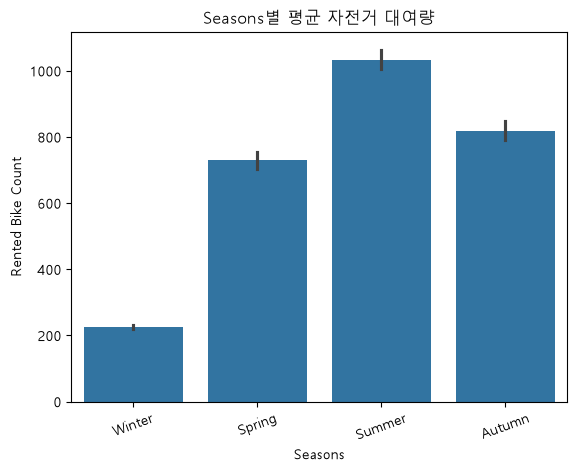

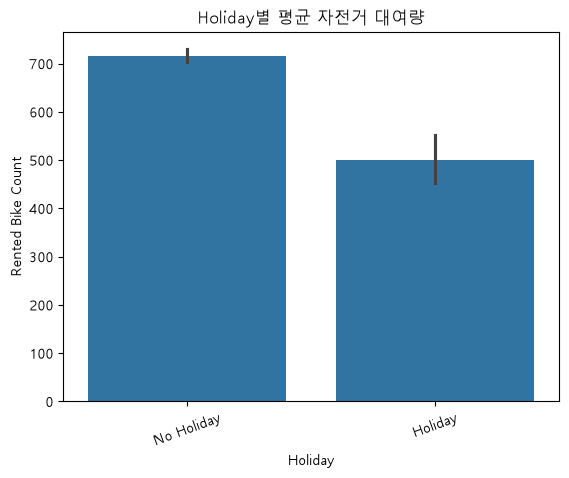

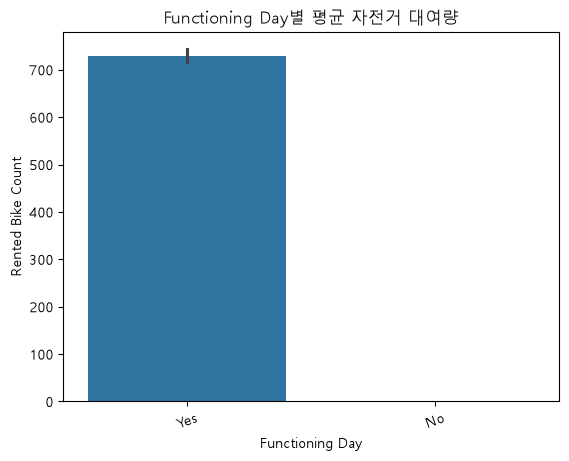

In [52]:
# 계절/공휴일/운영일별 평균 대여량 시각화
for col in['Seasons', 'Holiday', 'Functioning Day']:
    sns.barplot(data=bike_df, x=col, y='Rented Bike Count')
    plt.title(f'{col}별 평균 자전거 대여량')
    plt.xticks(rotation=20)
    plt.show()

c:\MCP\workspace\MCP#3_MLDL\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


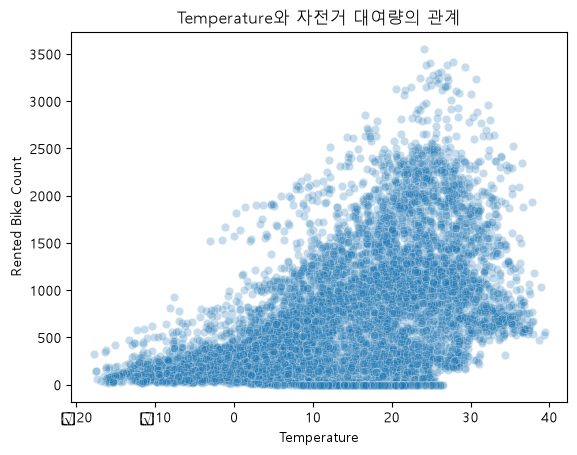

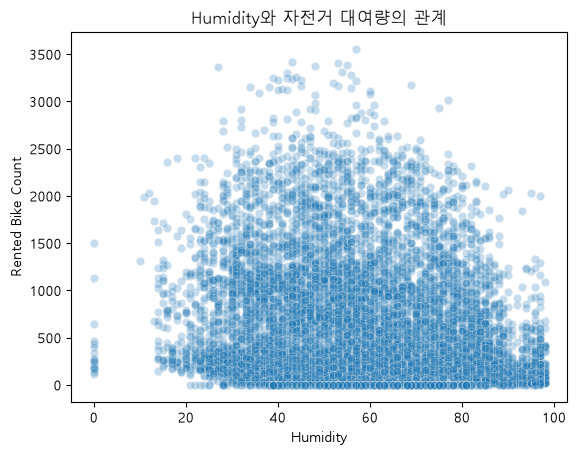

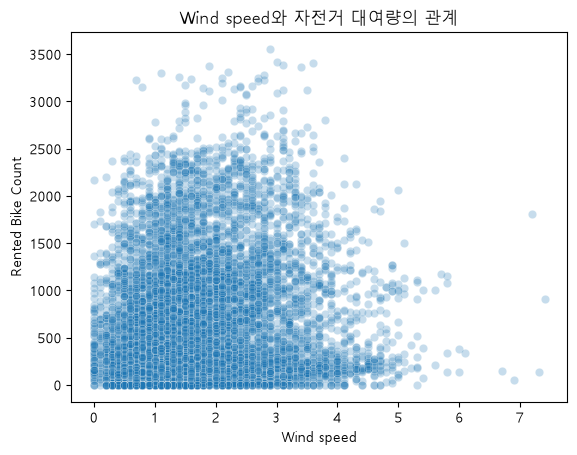

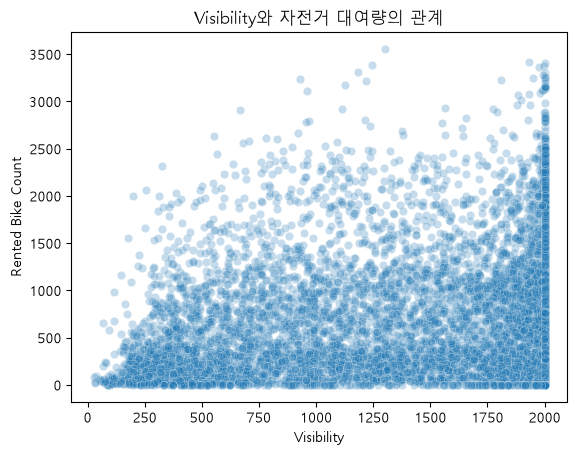

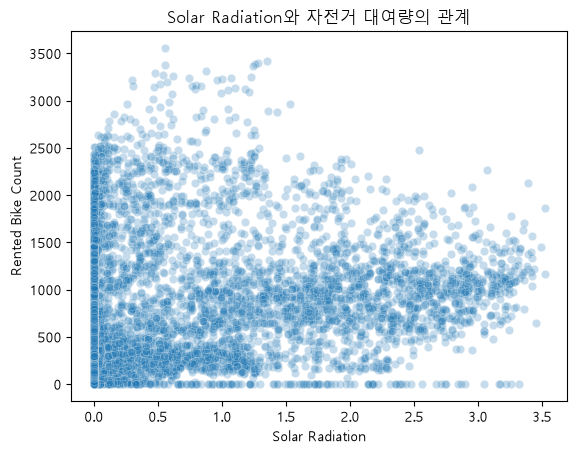

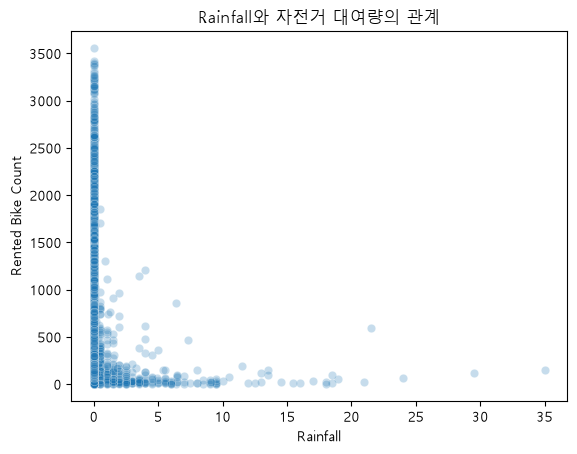

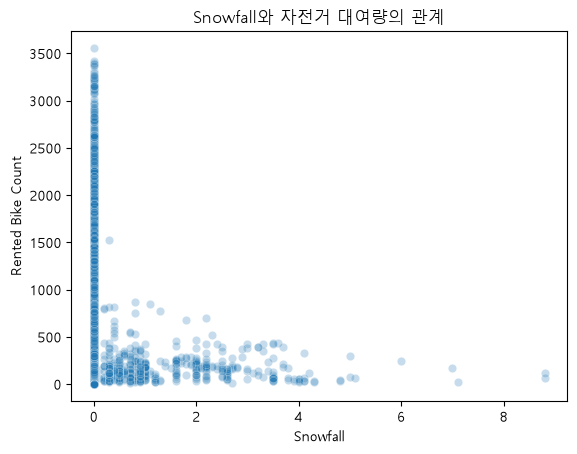

In [54]:
# 날씨 변수와 대여량 관계
weather_cols = ['Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Solar Radiation', 'Rainfall', 'Snowfall']

for col in weather_cols:
    sns.scatterplot(data=bike_df, x=col, y='Rented Bike Count', alpha=0.25)
    plt.title(f'{col}와 자전거 대여량의 관계')
    plt.show()

# **6. 운영일 데이터만 사용하기**
- 운영하지 않은 날은 실제 수요가 없어서 0에 가까움
- 운영일 수요를 예측하는 모델을 만들 때는 (Functioning Day == 'Yes') 데이터만 사용하는 것이 해석하기 쉬움
- 운영 여부 판단 또는 운영 캘린더 확인
- 운영하는 날에 한해서 수요 예측

In [58]:
model_df = bike_df[bike_df['Functioning Day'] == 'Yes'].copy()
model_df = model_df.drop(columns=['Functioning Day'])
print('전체 데이터 -', bike_df.shape)
print('운영일 데이터 -', model_df.shape)

전체 데이터 - (8760, 22)
운영일 데이터 - (8465, 21)


# **7. 학습/검증 데이터 분할**
- **시간 기준 분할**: 랜덤 분할은 미래 시점의 데이터가 학습 데이터가 섞일 수 있음 -> 수요 에측은 보통 과거를 보고 미래를 에측하므로 실무에서 시간 순서 기준 검증이 더 자연스러움